### **The Time-Dependent Schrodinger Equation**

The Time-Dependent Schrodinger Equation (in a position basis infinite boundaries) is

$$i\hbar{\frac{\partial}{\partial t}}\psi(x,t)=-{\frac{\hbar^{2}}{2m}}{\frac{\partial^{2}}{\partial x^{2}}}\psi(x,t)+V(x)\psi(x,t)\qquad\qquad\psi(0,t)=\psi(L,t)=0$$

We can absorb constants like $m$ and $\hbar$ into a dimensionless rescaling. Multiplying both sides by $mL^2$ where $L$ is the characteristic length of the problem (here we are bounded in length $L$)

$$i m L^{2}\hbar\frac{\partial}{\partial t}\psi=-\frac{1}{2}\hbar^{2}L^{2}\frac{\partial^{2}}{\partial x^{2}}\psi+m L^{2}V(x)\psi$$

Now choose the convention $\hbar = 1$ (So Joules=1/Seconds) and make the transformation


- $ x^\prime = x/L $
- $ t^\prime = t/m L^2 $
- $ V^\prime = m L^{2}V $

You can check that with the convention $\hbar = 1$, all of the three quantities above are dimensionless. The Schrodinger Equation with respect to these three variables becomes

$$i\frac{\partial}{\partial t^{\prime}}\psi=-\frac{1}{2}\frac{\partial^{2}}{\partial x^{\prime 2}}\psi+V^{\prime}(x)\psi$$

We solve this equation for $x^{\prime}$ and $t^{\prime}$ and then solve for $x$ and $t$ using

- $ x=Lx^{\prime} $
- $ t=(mL^2)t^{\prime} $
- $ V=(mL^2)^{-1}V^{\prime} $

**For all the numerical work we will drop the primes on $x^{\prime}, t^{\prime}$ and $V^{\prime}$ but know that we are working with the primed quantities.**

**Why the rescaling?**
We rewrite the equation in dimensionless form so the numerics are simpler and more stable. After solving, we can convert back to physical units if needed.

All four methods below use the same dimensionless form and the boundary conditions $\psi(0)=\psi(L)=0$.


### **Technique 1: Finite Difference**

Choose a discrete grid with spacing $\Delta x$ and $\Delta t$ and let $\psi_j^m = \psi(j \Delta x,m \Delta t)$

$$i\frac{{\psi}_{j}^{m+1}-\psi_{j}^{m}}{\Delta t}=-\frac{1}{2}\frac{\psi_{j+1}^{m}-2\psi_{j}^{m}+\psi_{j-1}^{m}}{\Delta x^{2}}+V(x)\psi_{j}^{m}$$

Rearrange the equation

$$\psi_{j}^{m+1}=\psi_{j}^{m}+\frac i2\frac{\Delta t}{\Delta x^{2}}\left(\psi_{j+1}^{m}-2\psi_{j}^{m}+\psi_{j-1}^{m}\right)-i\Delta t V(x)\psi_{j}^{m}$$

**What is happening here?**
We discretize space and time, then update $\psi$ using its neighbors and the potential. This direct method needs a small $\Delta t$.


Define all parameters of interest

**Key parameters**
We set the grid size, time step, initial state, and potential. The potential is an attractive well centered in the box.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter

import numba
from scipy.linalg import eigh_tridiagonal
import scienceplots

plt.style.use(['science', 'notebook', 'grid'])


In [2]:
L = 1.0
Nx = 301
Nt = 100000

dx = L / (Nx - 1)
dt = 1e-7
x = np.linspace(0.0, L, Nx)

MU = 0.5
SIGMA = 1/20
V0 = -1e4

def potential(x, mu=MU, sigma=SIGMA, V0=V0):
    return V0 * np.exp(-(x - mu)**2 / (2 * sigma**2))

def initial_state(x):
    return np.sqrt(2.0) * np.sin(np.pi * x)

psi0 = initial_state(x)
V = potential(x)


In [3]:
np.sum(np.absolute(psi0)**2)*dx

np.float64(1.0)

Look at $dt/dx^2$ (this parameter should be small for the finite difference method to work).

**Stability note**
Smaller values of $\Delta t/\Delta x^2$ usually give more stable results.


In [4]:
dt/dx**2

0.008999999999999998

The (dimensionless) potential we examine here is

$$
V(x) = -10^4 \exp(\frac{-(x-L/2)^2}{2(L/20)^2})
$$
which is essentially just a normal curve which can be specified more simply as $V(x)=-n(x,\mu = L/2, \sigma = L/20)$

Text(0, 0.5, '$V(x)$')

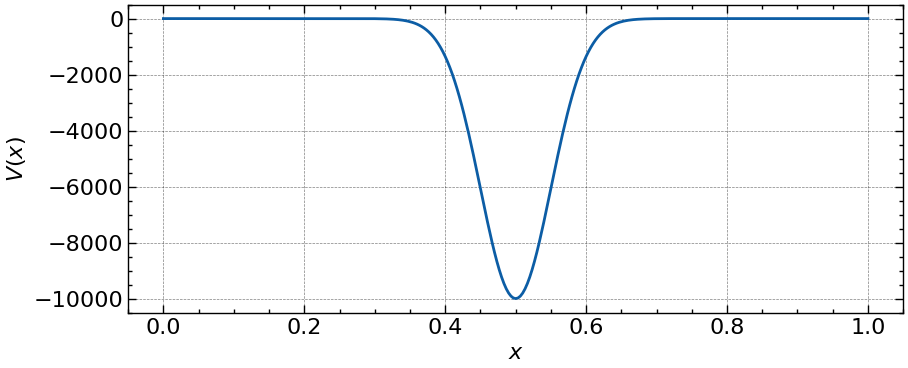

In [5]:
plt.figure(figsize=(10,4))
plt.plot(x,V)
plt.xlabel('$x$')
plt.ylabel('$V(x)$')

Construct the array of $\psi(x,t)$ (two dimensions: one for x and one for t)

Note: the $\psi$ array is allocated inside `explicit_fd()`.


Numba algorithm to implement the finite difference method

**What the next function does**
It steps forward in time and renormalizes the wavefunction each step so total probability stays $1$.


In [6]:
@numba.njit(cache=True)
def explicit_fd(psi0, V, dx, dt, Nt):
    Nx = psi0.size
    psi = np.zeros((Nt, Nx), dtype=np.complex128)
    psi[0] = psi0

    dx2 = dx * dx
    dt_dx2 = dt / dx2

    for t in range(Nt - 1):
        for i in range(1, Nx - 1):
            psi[t + 1, i] = (
                psi[t, i]
                + 0.5j * dt_dx2 * (psi[t, i + 1] - 2 * psi[t, i] + psi[t, i - 1])
                - 1j * dt * V[i] * psi[t, i]
            )

        norm = np.sqrt(np.sum(np.abs(psi[t + 1])**2) * dx)
        psi[t + 1] /= norm

    return psi


Compute $\psi(x,t)$ using method 1 (so we label m1)

In [7]:
psi_m1 = explicit_fd(psi0, V, dx, dt, Nt)


Plot for some given $m=10000$ (the dimensionless time is $t=m\Delta t$)

**Quick check**
We plot $|\psi|^2$ at a fixed time to confirm the shape looks reasonable and normalization is preserved.


np.float64(1.0000000000000002)

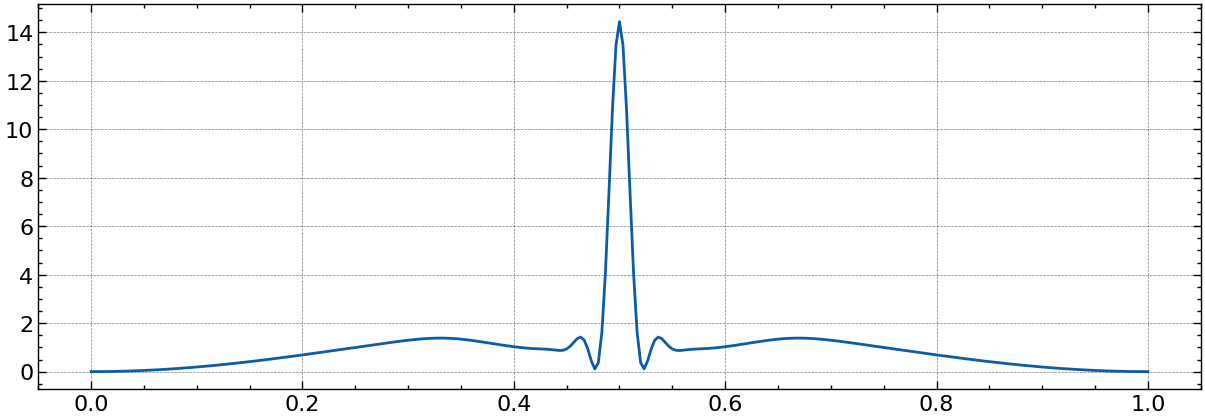

In [8]:
plt.figure(figsize=(15,5))
plt.plot(x, np.absolute(psi_m1[10000])**2)
np.sum(np.absolute(psi_m1[10000])**2)*dx

### **Technique 2: Eigenstate Evolution**
Find the $\psi_j$ and $E_j$'s that satisfy

$$-{\frac{1}{2}}{\frac{\partial^{2}}{\partial x^{2}}}\psi+V(x)\psi=E\psi$$

And then

$$\psi(x,t)=\sum_{j=0}^{\infty}c_{j}\psi_{j}(x)e^{-i E_{j}t} \qquad\qquad c_{j}=\int_{-\infty}^{\infty}\psi(x,0)\psi_{j}^{*}(x)dx$$

We compute a finite set of eigenstates and evolve the coefficients in time. Accuracy depends on the
number of eigenstates retained and the spatial resolution.


Create the grid and define the initial condition $\psi(x,0)$

We reuse $x$, $dx$, $\psi_0$, and $V$ from above for the eigenstate method.


Define the tridiagonal matrix required for solving for the eigenstates

**Why a tridiagonal matrix?**
The second-derivative finite difference produces a tridiagonal matrix, which makes eigenvalue computation fast.


In [9]:
d = 1 / dx**2 + V[1:-1]
e = -1 / (2 * dx**2) * np.ones(len(d) - 1)
w, v = eigh_tridiagonal(d, e)


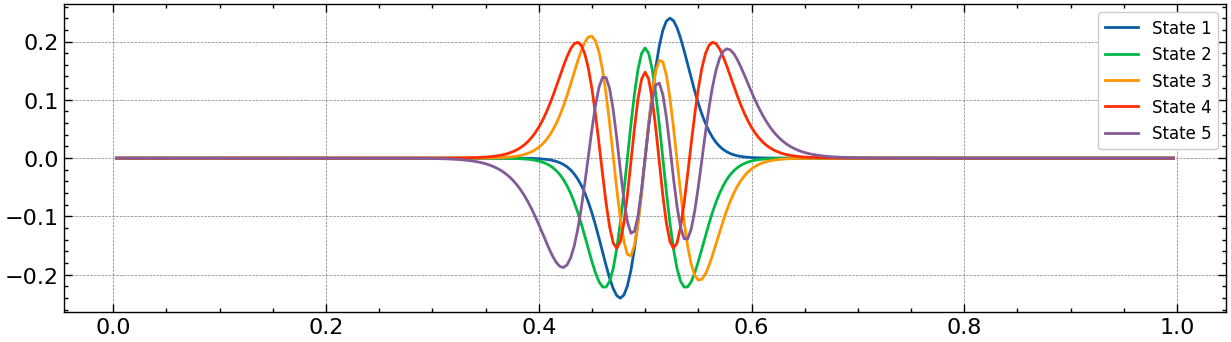

In [10]:
def plot_states(start, stop):
    plt.figure(figsize=(15,4))
    for i in range(start, stop + 1):
        plt.plot(x[1:-1], v.T[i], label=f'State {i}')
    plt.legend(loc='upper right', fontsize=12)

plot_states(1, 5)


Compute eigenstates $\psi_j$ and eigen-energies $E_j$, and use

$$
\psi(x,t) = \sum_{j=0}^{\infty} c_j \psi_j(x) e^{-iE_j t}
$$

$$
c_j = \int_{-\infty}^\infty \psi(x,0)\psi_j^{*}(x)dx
$$

to get the $\psi(x,t)$

**Building the solution**
We expand the initial state in eigenstates and add the time phase for each one to get the full evolution.


In [11]:
num_states = 70
E_js = w[:num_states]
psi_js = np.pad(v.T[:num_states], [(0, 0), (1, 1)], mode='constant')
cs = psi_js @ psi0

def psi_m2(t):
    return psi_js.T @ (cs * np.exp(-1j * E_js * t))


Plot the probability density at time $t=10000\Delta t$

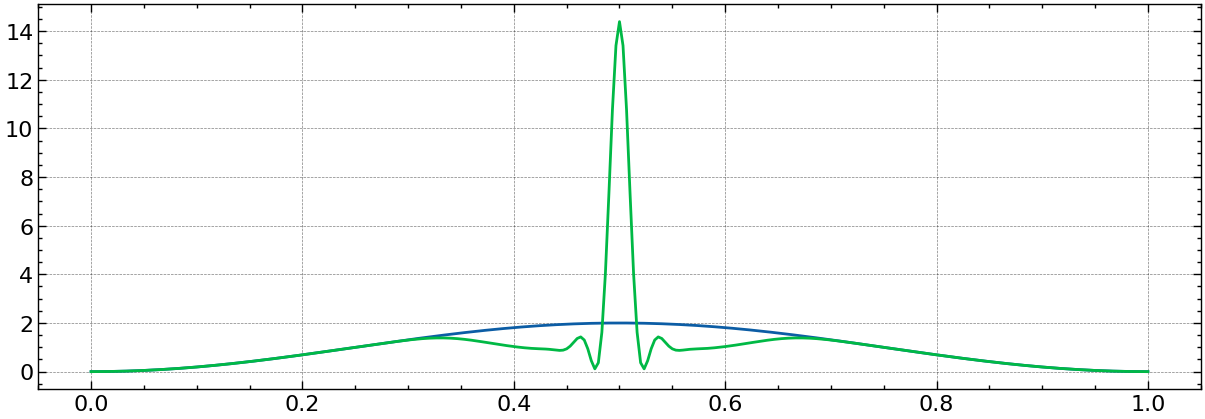

In [12]:
plt.figure(figsize=(15,5))
plt.plot(x, psi0**2)
plt.plot(x, np.absolute(psi_m2(10000 * dt))**2)

### **Technique 3: Crank-Nicolson (Implicit)**

We solve
$$(I + i\Delta t/2 \; H)\psi^{n+1} = (I - i\Delta t/2 \; H)\psi^n$$
where $H=-\frac{1}{2}\partial_{xx}+V(x)$ using a tridiagonal solver each step.
This method is unconditionally stable, so we can use a larger $\Delta t$ than the explicit scheme.


We reuse the same grid and potential for the Crank-Nicolson method; only the time step changes.


In [13]:
# Crank-Nicolson parameters (use fewer steps but same total time as Method 1)
T_total = (Nt - 1) * dt
Nt_cn = 2000
dt_cn = T_total / (Nt_cn - 1)

# Reuse the same grid and potential
x_cn = x
dx_cn = dx
psi0_cn = psi0
V_cn = V

@numba.njit(cache=True)
def thomas_solve(a, b, c, d):
    n = b.size
    cp = np.empty(n - 1, dtype=np.complex128)
    dp = np.empty(n, dtype=np.complex128)

    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]

    for i in range(1, n - 1):
        denom = b[i] - a[i - 1] * cp[i - 1]
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i - 1] * dp[i - 1]) / denom

    denom = b[n - 1] - a[n - 2] * cp[n - 2]
    dp[n - 1] = (d[n - 1] - a[n - 2] * dp[n - 2]) / denom

    x = np.empty(n, dtype=np.complex128)
    x[n - 1] = dp[n - 1]
    for i in range(n - 2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i + 1]
    return x

@numba.njit(cache=True)
def crank_nicolson(psi0, Nt, dx, dt, V):
    Nx = psi0.size
    N = Nx - 2

    diag = 1 / dx**2 + V[1:-1]
    off = -1 / (2 * dx**2) * np.ones(N - 1)

    a_diag = 1 + 1j * dt / 2 * diag
    a_off = 1j * dt / 2 * off
    b_diag = 1 - 1j * dt / 2 * diag
    b_off = -1j * dt / 2 * off

    psi = np.zeros((Nt, Nx), dtype=np.complex128)
    psi[0] = psi0

    for t in range(Nt - 1):
        rhs = b_diag * psi[t, 1:-1]
        rhs[:-1] += b_off * psi[t, 2:-1]
        rhs[1:] += b_off * psi[t, 1:-2]
        psi[t + 1, 1:-1] = thomas_solve(a_off, a_diag, a_off, rhs)

        norm = np.sqrt(np.sum(np.abs(psi[t + 1])**2) * dx)
        psi[t + 1] /= norm

    return psi

psi_cn = crank_nicolson(psi0_cn, Nt_cn, dx_cn, dt_cn, V_cn)


### **Technique 4: Split-Operator (Strang Splitting)**

We alternate half-steps of the potential with a kinetic step in the sine basis,
which enforces the $\psi(0)=\psi(L)=0$ boundary conditions.


In [14]:
try:
    from scipy.fft import dst, idst
except ImportError:
    from scipy.fftpack import dst, idst

# Split-operator parameters (match the same total time)
T_total = (Nt - 1) * dt
Nt_so = 2000
dt_so = T_total / (Nt_so - 1)

# Reuse the same grid and potential
x_so = x
dx_so = dx
psi0_so = psi0
V_so = V

N = x_so.size - 2
V_in = V_so[1:-1]
k = np.arange(1, N + 1) * np.pi / L

expV_half = np.exp(-1j * V_in * dt_so / 2)
expK = np.exp(-1j * (k**2) * dt_so / 2)

psi_so = np.zeros((Nt_so, x_so.size), dtype=np.complex128)
psi_so[0] = psi0_so

for t in range(0, Nt_so - 1):
    psi_in = psi_so[t, 1:-1] * expV_half
    psi_k = dst(psi_in, type=1, norm='ortho')
    psi_k *= expK
    psi_in = idst(psi_k, type=1, norm='ortho')
    psi_so[t + 1, 1:-1] = psi_in * expV_half

    norm = np.sqrt(np.sum(np.abs(psi_so[t + 1])**2) * dx_so)
    psi_so[t + 1] /= norm


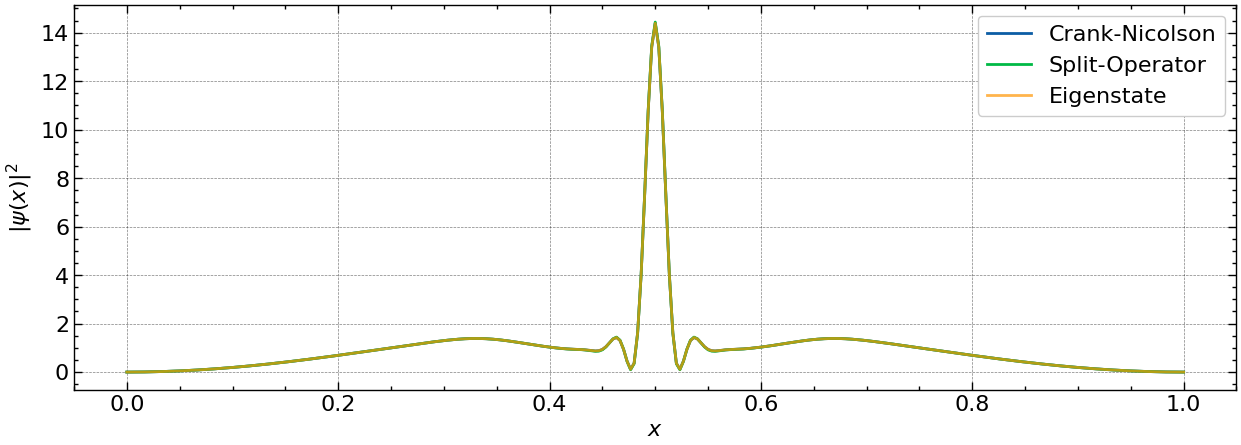

In [15]:
t_eval = 10000 * dt
T_total = (Nt - 1) * dt

plt.figure(figsize=(15,5))

# Method 3: Crank-Nicolson
if 'psi_cn' in globals():
    Nt_cn = psi_cn.shape[0]
    dt_cn = T_total / (Nt_cn - 1)
    i_cn = min(int(round(t_eval / dt_cn)), Nt_cn - 1)
    plt.plot(x, np.abs(psi_cn[i_cn])**2, label='Crank-Nicolson')
else:
    print("[Info] Run Method 3 (Crank-Nicolson) cell to compute psi_cn.")

# Method 4: Split-Operator
if 'psi_so' in globals():
    Nt_so = psi_so.shape[0]
    dt_so = T_total / (Nt_so - 1)
    i_so = min(int(round(t_eval / dt_so)), Nt_so - 1)
    plt.plot(x, np.abs(psi_so[i_so])**2, label='Split-Operator')
else:
    print("[Info] Run Method 4 (Split-Operator) cell to compute psi_so.")

# Method 2: Eigenstate
if 'psi_m2' in globals():
    plt.plot(x, np.abs(psi_m2(t_eval))**2, label='Eigenstate', alpha=0.7)
else:
    print("[Info] Run Method 2 (Eigenstate) cell to compute psi_m2.")

plt.xlabel('$x$')
plt.ylabel(r'$|\psi(x)|^2$')
plt.legend()


### **Animation**

Now we make an animation that shows the results of all four techniques:
- Method 1: Explicit finite difference
- Method 2: Eigenstate evolution
- Method 3: Crank-Nicolson (implicit)
- Method 4: Split-operator (Strang splitting)

and verify that they agree.


**Goal of the animation**
We compare all four methods over time to confirm they give the same result in practice.


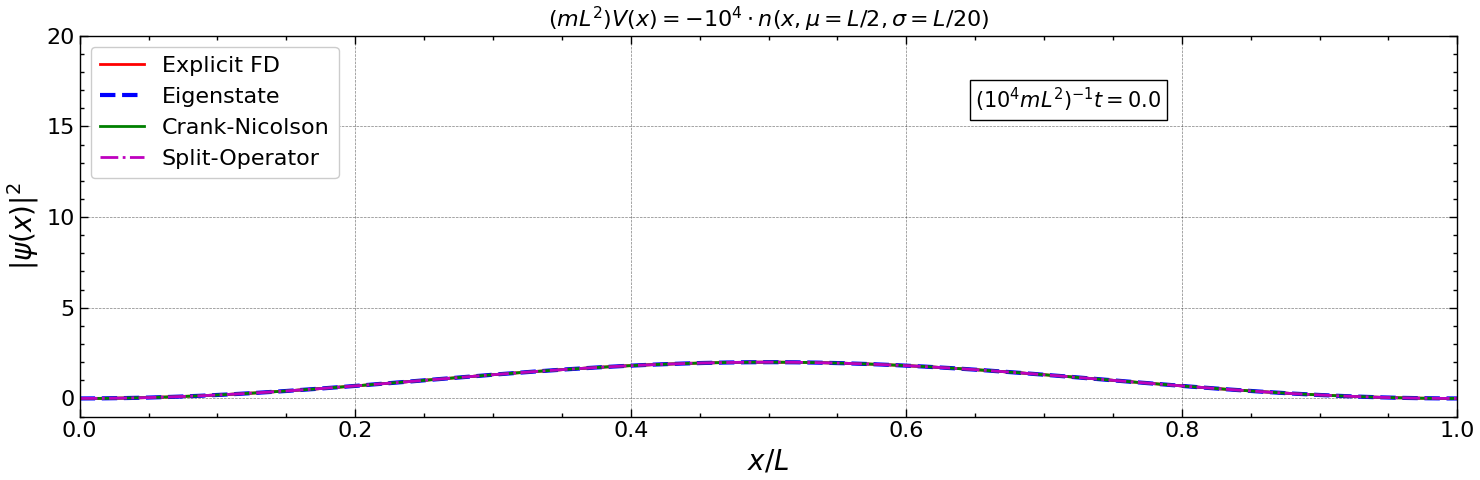

In [16]:
T_total = (Nt - 1) * dt

dt_cn = T_total / (psi_cn.shape[0] - 1) if 'psi_cn' in globals() else None
dt_so = T_total / (psi_so.shape[0] - 1) if 'psi_so' in globals() else None

def animate(i):
    t = min(100 * i * dt, T_total)
    i_fd = min(100 * i, psi_m1.shape[0] - 1)
    ln1.set_data(x, np.abs(psi_m1[i_fd])**2)

    if 'psi_m2' in globals():
        ln2.set_data(x, np.abs(psi_m2(t))**2)
    else:
        ln2.set_data([], [])

    if dt_cn is not None:
        i_cn = min(int(round(t / dt_cn)), psi_cn.shape[0] - 1)
        ln3.set_data(x, np.abs(psi_cn[i_cn])**2)
    else:
        ln3.set_data([], [])

    if dt_so is not None:
        i_so = min(int(round(t / dt_so)), psi_so.shape[0] - 1)
        ln4.set_data(x, np.abs(psi_so[i_so])**2)
    else:
        ln4.set_data([], [])

    time_text.set_text(r'$(10^4 mL^2)^{-1}t=$' + '{:.1f}'.format(t * 1e4))

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

ln1, = plt.plot([], [], 'r-', lw=2, markersize=8, label='Explicit FD')
ln2, = plt.plot([], [], 'b--', lw=3, markersize=8, label='Eigenstate')
ln3, = plt.plot([], [], 'g-', lw=2, markersize=6, label='Crank-Nicolson')
ln4, = plt.plot([], [], 'm-.', lw=2, markersize=6, label='Split-Operator')
time_text = ax.text(0.65, 16, '', fontsize=15, bbox=dict(facecolor='white', edgecolor='black'))

ax.set_ylim(-1, 20)
ax.set_xlim(0, 1)
ax.set_ylabel(r'$|\psi(x)|^2$', fontsize=20)
ax.set_xlabel('$x/L$', fontsize=20)
ax.legend(loc='upper left')
ax.set_title(r'$(mL^2)V(x) = -10^4 \cdot n(x, \mu=L/2,\sigma= L/20)$')
plt.tight_layout()
max_frames = min(1000, (psi_m1.shape[0] - 1) // 100 + 1)
ani = animation.FuncAnimation(fig, animate, frames=max_frames, interval=50)
ani.save('TD.gif', writer='pillow', fps=50, dpi=100)


### **Method limits (stability and accuracy)**

- Method 1 (explicit finite difference) is conditionally stable; keep $\Delta t/\Delta x^2$ small and monitor the norm.
- Method 2 (eigenstate evolution) is exact in time for the chosen basis, but accuracy depends on eigenstate truncation and grid resolution.
- Method 3 (Crank-Nicolson) is unconditionally stable and second-order in time.
- Method 4 (split-operator) is stable for reasonable $\Delta t$ when the potential is well-resolved.
